# 10 - Integrating Histology Features with Gene Expression

## Learning objectives
1. Correlate image features with selected genes and with gene-signature scores.
2. Train a **regression** model to predict a marker gene from image features (report R^2).
3. Train a **classifier** to predict the transcriptomic cluster from image features
   (accuracy, balanced accuracy, confusion matrix).
4. Reason about the limitations of histology->expression prediction.

## Concept
We now test the central question: **how much molecular information is in the morphology?**
This is a standard supervised-ML setup - features (image) -> target (expression/cluster) -
with train/test splits and the evaluation metrics you already know.


In [1]:
# --- Standard setup: make `utils` importable and seed RNGs ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'utils').exists():
    ROOT = ROOT.parent  # in case the notebook is opened from a subfolder
sys.path.insert(0, str(ROOT))

from utils import st_helpers as st
st.set_seeds()  # reproducibility (seed = 0)
print('Project root:', st.project_root())


Project root: /Users/justin/Documents/SpatialTranscriptomics-Tutorial


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

adata = st.load_adata('adata_features.h5ad')
feat_names = list(adata.uns['img_feature_names'])
Ximg = pd.DataFrame(adata.obsm['img_features'], columns=feat_names, index=adata.obs_names)
print('image features:', Ximg.shape)
Ximg.head()


image features: (2688, 15)


,mean_r,std_r,mean_g,std_g,mean_b,std_b,hematoxylin_mean,eosin_mean,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,entropy_mean,edge_density,tissue_fraction
AAACAAGTATCTCCCA-1,106.852041,15.295176,78.030612,12.095246,112.418367,9.566548,0.078339,0.005828,116.802198,0.128344,0.066276,0.615750,3.916804,0.036150,1.0
AAACAATCTACTAGCA-1,110.051020,15.962247,61.637755,11.356307,108.943878,12.221256,0.071860,0.026194,204.409341,0.111739,0.062224,0.295124,3.946263,0.039436,1.0
AAACACCAATAACTGC-1,112.678571,14.469311,89.943878,12.446699,114.841837,10.316446,0.072470,0.001309,190.851648,0.118017,0.061551,0.362233,3.927076,0.036881,1.0
AAACAGAGCGACTCCT-1,114.836735,7.815727,82.408163,14.294167,112.826531,8.162915,0.067703,0.009235,65.313187,0.166493,0.066277,0.753604,3.764341,0.024994,1.0
AAACCGGGTAGGTACC-1,110.367347,14.135920,78.566327,12.075895,112.918367,10.247621,0.073735,0.007567,241.975275,0.082241,0.060747,0.157754,3.938982,0.032852,1.0


### 1. Correlate image features with a gene-signature score
We build module scores (`sc.tl.score_genes`) for a couple of programs, then correlate them
with the image features. Module scoring averages a gene set's expression per spot - a
robust target less noisy than a single gene.

In [3]:
# Existence-checked signatures (neuronal & glial/myelin for mouse brain).
neuronal = st.genes_present(adata, ['Snap25', 'Slc17a7', 'Rbfox3', 'Syt1', 'Meg3'])
glial = st.genes_present(adata, ['Mbp', 'Plp1', 'Mobp', 'Gfap', 'Aqp4'])
if neuronal:
    sc.tl.score_genes(adata, neuronal, score_name='sig_neuronal', random_state=st.SEED)
if glial:
    sc.tl.score_genes(adata, glial, score_name='sig_glial', random_state=st.SEED)
sig_cols = [c for c in ['sig_neuronal', 'sig_glial'] if c in adata.obs]
print('signatures:', sig_cols)


signatures: ['sig_neuronal', 'sig_glial']


/opt/homebrew/anaconda3/envs/spatial-tx/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/anaconda3/envs/spatial-tx/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


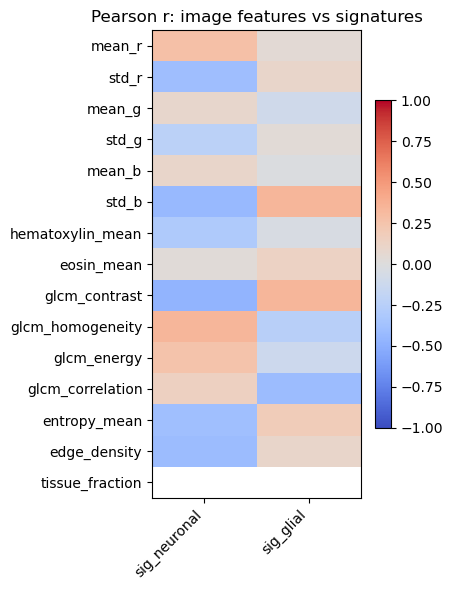

,sig_neuronal,sig_glial
mean_r,0.277613,0.039377
std_r,-0.393582,0.099420
mean_g,0.092859,-0.095698
std_g,-0.229011,0.038011
mean_b,0.100892,-0.018306
std_b,-0.437180,0.337493
hematoxylin_mean,-0.297765,-0.042460
eosin_mean,0.026719,0.129967
glcm_contrast,-0.468353,0.342443
glcm_homogeneity,0.337539,-0.248368


In [4]:
# Correlation heatmap: image features (rows) vs signature scores (cols).
corr = pd.DataFrame(index=feat_names, columns=sig_cols, dtype=float)
for s in sig_cols:
    for f in feat_names:
        corr.loc[f, s] = np.corrcoef(Ximg[f], adata.obs[s])[0, 1]
corr = corr.astype(float)

fig, ax = plt.subplots(figsize=(4.5, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(sig_cols))); ax.set_xticklabels(sig_cols, rotation=45, ha='right')
ax.set_yticks(range(len(feat_names))); ax.set_yticklabels(feat_names)
ax.set_title('Pearson r: image features vs signatures')
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()
corr


**Expected output:** a heatmap; e.g. hematoxylin/nuclear-density and texture features tend
to correlate with the neuronal/glial signatures (sign depends on the tissue).

### 2. Regression - predict a marker gene from image features
Pick an available marker, build the target from log-normalized expression, and fit a
Random Forest regressor with a train/test split.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

target_gene = st.first_present_gene(adata, ['Mbp', 'Plp1', 'Snap25', 'Gfap'])
y = np.asarray(adata[:, target_gene].X.todense()).ravel() if hasattr(adata[:, target_gene].X, 'todense') else np.asarray(adata[:, target_gene].X).ravel()
print('Predicting expression of', target_gene)

Xtr, Xte, ytr, yte = train_test_split(Ximg.values, y, test_size=0.25, random_state=st.SEED)
reg = RandomForestRegressor(n_estimators=300, random_state=st.SEED, n_jobs=-1)
reg.fit(Xtr, ytr)
pred = reg.predict(Xte)
r2 = r2_score(yte, pred)
r = pearsonr(yte, pred)[0]
print(f'Test R^2  = {r2:.3f}')
print(f'Test r    = {r:.3f}')


Predicting expression of Mbp
Test R^2  = 0.508
Test r    = 0.716


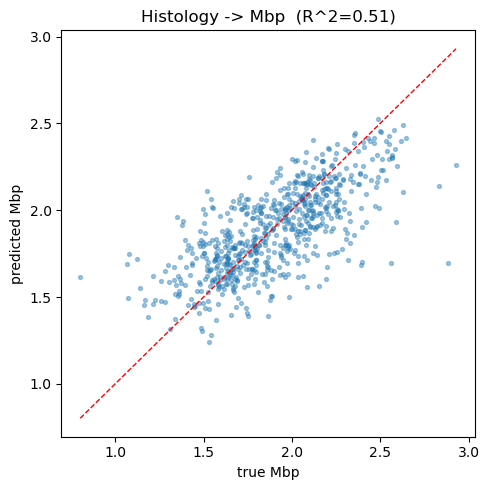

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(yte, pred, s=8, alpha=0.4)
lims = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set(xlabel=f'true {target_gene}', ylabel=f'predicted {target_gene}',
       title=f'Histology -> {target_gene}  (R^2={r2:.2f})')
plt.tight_layout(); plt.show()


### 3. Classification - predict transcriptomic cluster from image features
Can morphology recover the expression-defined domains? We classify the Leiden cluster from
image features and report accuracy, **balanced** accuracy (robust to class imbalance), and
a confusion matrix.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Encode the string cluster ids to integers. RandomForest's class_weight='balanced'
# expects integer-encoded classes; encoding keeps the call robust across versions.
le = LabelEncoder()
labels = le.fit_transform(adata.obs['clusters'].astype(str).values)
Xtr, Xte, ltr, lte = train_test_split(
    Ximg.values, labels, test_size=0.25, random_state=st.SEED, stratify=labels)
clf = RandomForestClassifier(n_estimators=400, random_state=st.SEED, n_jobs=-1,
                             class_weight='balanced')
clf.fit(Xtr, ltr)
lpred = clf.predict(Xte)
acc = accuracy_score(lte, lpred)
bacc = balanced_accuracy_score(lte, lpred)
print(f'Accuracy          = {acc:.3f}')
print(f'Balanced accuracy = {bacc:.3f}')


Accuracy          = 0.438
Balanced accuracy = 0.427


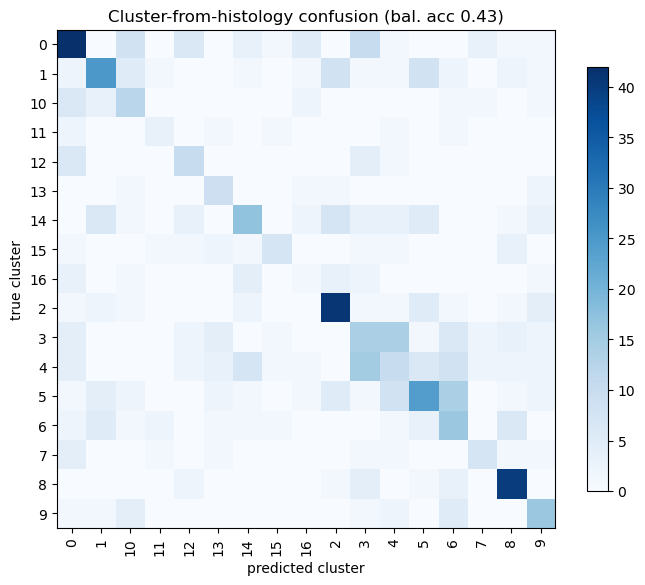

In [8]:
class_ids = np.arange(len(le.classes_))   # integer ids used by the classifier
class_names = list(le.classes_)            # original (string) cluster labels
cm = confusion_matrix(lte, lpred, labels=class_ids)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=90)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set(xlabel='predicted cluster', ylabel='true cluster',
       title=f'Cluster-from-histology confusion (bal. acc {bacc:.2f})')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()


**Expected output:** balanced accuracy well above chance (chance ~ 1/n_clusters) but far
from perfect - morphology predicts domain identity *partially*. The confusion matrix shows
morphologically similar domains getting mixed up.

### Save metrics

In [9]:
metrics = pd.DataFrame([
    {'task': 'regression', 'target': target_gene, 'metric': 'R2', 'value': r2},
    {'task': 'regression', 'target': target_gene, 'metric': 'pearson_r', 'value': r},
    {'task': 'classification', 'target': 'clusters', 'metric': 'accuracy', 'value': acc},
    {'task': 'classification', 'target': 'clusters', 'metric': 'balanced_accuracy', 'value': bacc},
])
metrics_csv = st.outputs_dir() / 'integration_metrics.csv'
st.save_root_result_table(
    metrics, metrics_csv, result_name='integration_metrics',
    upstream_lineage={'adata_features': st.root_artifact_lineage('adata_features.h5ad')},
)
print('Wrote', metrics_csv)
metrics


Wrote /Users/justin/Documents/SpatialTranscriptomics-Tutorial/outputs/integration_metrics.csv


,task,target,metric,value
0,regression,Mbp,R2,0.507789
1,regression,Mbp,pearson_r,0.715545
2,classification,clusters,accuracy,0.437500
3,classification,clusters,balanced_accuracy,0.427169


## Limitations (read this carefully)
- **Spot-level averaging** - each spot mixes cells, blurring the morphology<->expression
  link; sub-spot heterogeneity is invisible.
- **Registration uncertainty** - small misalignments mean a patch may not exactly cover the
  cells that produced its counts.
- **Tissue heterogeneity & batch** - stain/scanner variation changes image features; one
  section cannot prove generalization.
- **Morphology does not fully determine state** - cells that look alike can differ
  molecularly. Expect partial, not perfect, prediction. Correlation is not causation.

## Interpretation
Histology features carry real but incomplete molecular signal: we can predict broad
programs and domains from morphology, but not exact expression. That is the honest,
useful answer.

## What this means biologically
Morphology and molecular state are coupled (structure follows function), which is why
pathologists can infer so much from H&E. ST quantifies that coupling - and its limits -
enabling models that read molecular hints from cheap, ubiquitous histology.

---
**Next:** `11_cell_type_annotation_and_deconvolution_optional.ipynb`.
